In [ ]:
# ============================================================
# Anemia detection (Anemic vs Healthy) using CNN+ViT hybrid
# End-to-end: subset creation, data pipeline, model, training,
# evaluation, and plots.
# Colab-ready. Adjust DATASET_PATH to your Drive location.
# ============================================================

# 1. Mount Google Drive (skip if not using Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except:
    IN_COLAB = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Paths and setup
import os, random, math, shutil, pathlib

DATASET_PATH = "/content/drive/MyDrive/AneN_Dasaset"  # <-- adjust path
WORK_DIR = "/content/Anemia_subset_4k"
os.makedirs(WORK_DIR, exist_ok=True)

classes = ["Anemic_individuals", "Healthy_individuals"]

In [ ]:
# 3. Create 2000-image subset (1000 per class) and split 70/15/15
files_by_class = {}
SAMPLES_PER_CLASS = 1000
for cls in classes:
    cls_dir = pathlib.Path(DATASET_PATH) / cls
    files = [str(p) for p in cls_dir.glob("*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]
    random.shuffle(files)
    if len(files) < SAMPLES_PER_CLASS:
        raise ValueError(f"Not enough images in {cls}: found {len(files)}, need {SAMPLES_PER_CLASS}")
    files_by_class[cls] = files[:SAMPLES_PER_CLASS]

splits = {"train": 0.7, "val": 0.15, "test": 0.15}
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(WORK_DIR, split, cls), exist_ok=True)

for cls in classes:
    files = files_by_class[cls]
    n = len(files)
    n_train = math.floor(n * splits["train"])     # 700 per class
    n_val   = math.floor(n * splits["val"])       # 150 per class
    train_files = files[:n_train]
    val_files   = files[n_train:n_train+n_val]
    test_files  = files[n_train+n_val:]

    for f in train_files:
        shutil.copy(f, os.path.join(WORK_DIR, "train", cls, os.path.basename(f)))
    for f in val_files:
        shutil.copy(f, os.path.join(WORK_DIR, "val", cls, os.path.basename(f)))
    for f in test_files:
        shutil.copy(f, os.path.join(WORK_DIR, "test", cls, os.path.basename(f)))

print("Subset created at:", WORK_DIR)

Subset created at: /content/Anemia_subset_4k


In [ ]:
# 4. Imports and data pipeline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

# Data augmentation layer
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

def make_dataset(split_dir, shuffle, augment=False):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        split_dir,
        labels="inferred",
        label_mode="binary",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle
    )
    def preprocess(x, y):
        x = tf.cast(x, tf.float32) / 255.0
        mean = tf.constant([0.485, 0.456, 0.406], shape=(1,1,1,3))
        std  = tf.constant([0.229, 0.224, 0.225], shape=(1,1,1,3))
        x = (x - mean) / std
        return x, y
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    return ds.cache().prefetch(AUTOTUNE)

train_ds = make_dataset(os.path.join(WORK_DIR, "train"), shuffle=True, augment=True)
val_ds   = make_dataset(os.path.join(WORK_DIR, "val"), shuffle=False, augment=False)
test_ds  = make_dataset(os.path.join(WORK_DIR, "test"), shuffle=False, augment=False)


Found 1818 files belonging to 2 classes.
Found 556 files belonging to 2 classes.
Found 564 files belonging to 2 classes.


In [ ]:
# 5. CNN + ViT hybrid model
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_tokens, embed_dim):
        super().__init__()
        self.pos_emb = self.add_weight(
            shape=(1, num_tokens, embed_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_embedding"
        )

    def call(self, x):
        return x + self.pos_emb  # broadcast along batch

def transformer_block(x, num_heads, mlp_dim, dropout=0.1, name_prefix="blk"):
    x_norm = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln1")(x)
    mha_layer = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=x.shape[-1],
        dropout=dropout,
        output_shape=x.shape[-1],
        name=f"{name_prefix}_mha"
    )
    attn_out, attn_scores = mha_layer(x_norm, x_norm, return_attention_scores=True)
    x = layers.Add(name=f"{name_prefix}_mha_res")([x, attn_out])

    x_norm = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln2")(x)
    mlp = layers.Dense(mlp_dim, activation="gelu", name=f"{name_prefix}_mlp_fc1")(x_norm)
    mlp = layers.Dropout(dropout, name=f"{name_prefix}_mlp_drop")(mlp)
    mlp = layers.Dense(x.shape[-1], name=f"{name_prefix}_mlp_fc2")(mlp)
    x = layers.Add(name=f"{name_prefix}_mlp_res")([x, mlp])
    return x, attn_scores

def build_cnn_vit(input_shape=(224,224,3),
                  cnn_channels=(32,64,128),
                  patch_size=4,
                  embed_dim=256,
                  num_transformer_blocks=4,
                  num_heads=8,
                  mlp_dim=512,
                  dropout=0.1):
    inputs = keras.Input(shape=input_shape, name="input")
    x = inputs
    for i, c in enumerate(cnn_channels):
        x = layers.Conv2D(c, 3, padding="same", activation="relu", name=f"conv_{i}_a")(x)
        x = layers.Conv2D(c, 3, padding="same", activation="relu", name=f"conv_{i}_b")(x)
        x = layers.MaxPool2D(name=f"pool_{i}")(x)

    # Resize to make divisible by patch_size
    h, w = x.shape[1], x.shape[2]
    target_h = (h // patch_size) * patch_size
    target_w = (w // patch_size) * patch_size
    x = layers.Resizing(target_h, target_w)(x)

    # Patch projection
    x = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")(x)
    h_tokens, w_tokens = x.shape[1], x.shape[2]
    num_tokens = h_tokens * w_tokens

    x = layers.Reshape((num_tokens, embed_dim), name="flatten_tokens")(x)
    x = AddPositionEmbedding(num_tokens=num_tokens, embed_dim=embed_dim)(x)

    attn_scores_list = []
    for b in range(num_transformer_blocks):
        x, attn_scores = transformer_block(x, num_heads=num_heads, mlp_dim=mlp_dim, dropout=dropout, name_prefix=f"blk{b}")
        attn_scores_list.append(attn_scores)

    x = layers.LayerNormalization(epsilon=1e-6, name="pre_pool_ln")(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)

    x = layers.Dropout(dropout)(x)
    x = layers.Dense(mlp_dim, activation="gelu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="pred")(x)

    return keras.Model(inputs, outputs, name="cnn_vit_hybrid")

# Build and compile model
model = build_cnn_vit()
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)
model.summary()


Model: "cnn_vit_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_0_a (Conv2D)   │ (None, 224, 224,  │        896 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_0_b (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv_0_a[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_0              │ (None, 112, 112,  │          0 │ conv_0_b[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_a (Conv2D)   │ (None, 112, 112,  │     18,496 │ pool_0[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_b (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv_1_a[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_1              │ (None, 56, 56,    │          0 │ conv_1_b[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2_a (Conv2D)   │ (None, 56, 56,    │     73,856 │ pool_1[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2_b (Conv2D)   │ (None, 56, 56,    │    147,584 │ conv_2_a[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, 28, 28,    │          0 │ conv_2_b[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 28, 28,    │          0 │ pool_2[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 256) │    524,544 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_tokens      │ (None, 49, 256)   │          0 │ conv2d[0][0]      │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_position_embed… │ (None, 49, 256)   │     12,544 │ flatten_tokens[0… │
│ (AddPositionEmbedd… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ blk0_ln1            │ (None, 49, 256)   │        512 │ add_position_emb… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ blk0_mha            │ [(None, 49, 256), │  2,103,552 │ blk0_ln1[0][0],   │
│ (MultiHeadAttentio… │ (None, 8, 49,     │            │ blk0_ln1[0][0]    │
│                     │ 49)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ blk0_mha_res (Add)  │ (None, 49, 256)   │          0 │ add_position_emb

 Total params: 10,426,657 (39.77 MB)

 Trainable params: 10,426,657 (39.77 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6. Training
callbacks = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor="val_loss"),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss")
]

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - acc: 0.5264 - auc: 0.5245 - loss: 0.7952 - precision: 0.5035 - recall: 0.4881 - val_acc: 0.5036 - val_auc: 0.5902 - val_loss: 0.7310 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 205ms/step - acc: 0.4967 - auc: 0.4933 - loss: 0.7266 - precision: 0.4741 - recall: 0.4678 - val_acc: 0.5036 - val_auc: 0.4515 - val_loss: 0.7127 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 212ms/step - acc: 0.5172 - auc: 0.5009 - loss: 0.7120 - precision: 0.4936 - recall: 0.4850 - val_acc: 0.5036 - val_auc: 0.5329 - val_loss: 0.7099 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 211ms/step - acc: 0.5143 - auc: 0.5102 - loss: 0.7025 - precision: 0.4857 - recall: 0.4092 - val_acc: 0.5036 - val_auc: 0.5000 - val_loss: 0.6932 - val_p


Thresholded test accuracy: 0.5160

=== Classification Report ===
                     precision    recall  f1-score   support

 Anemic_individuals       0.51      1.00      0.67       283
Healthy_individuals       1.00      0.03      0.06       281

           accuracy                           0.52       564
          macro avg       0.75      0.51      0.36       564
       weighted avg       0.75      0.52      0.37       564

Confusion matrix:
 [[283   0]
 [273   8]]


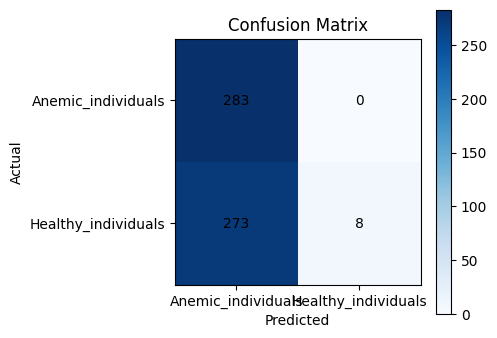

<Figure size 640x480 with 0 Axes>

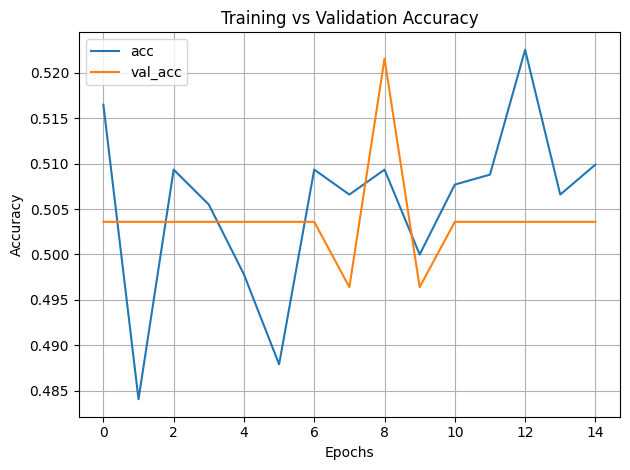

<Figure size 640x480 with 0 Axes>

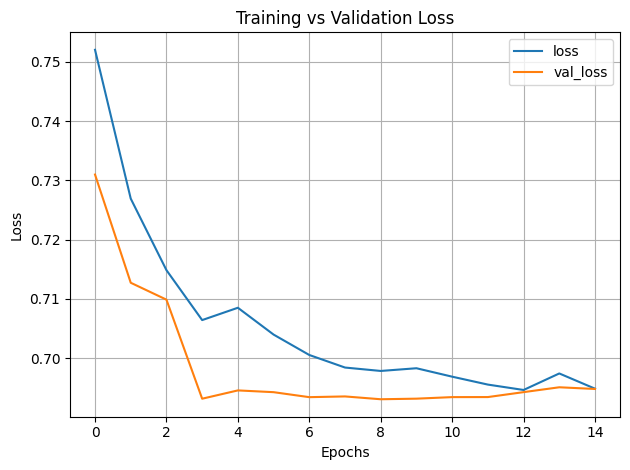

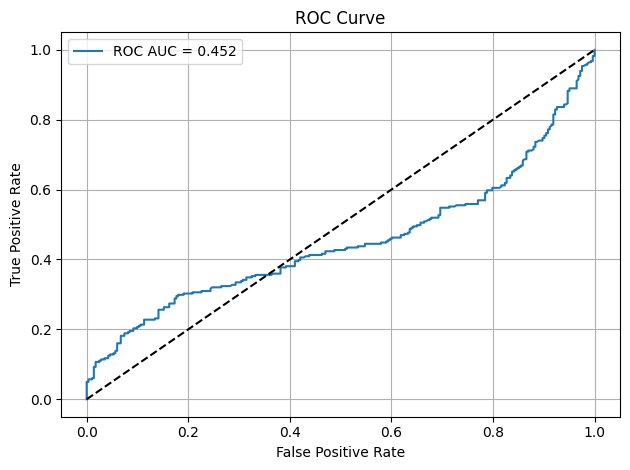

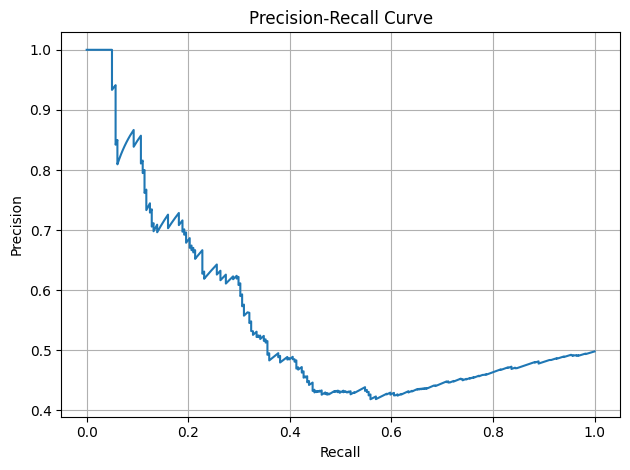

In [ ]:
# 7. Evaluation + Plots
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import pandas as pd
import numpy as np

# Predict on test set
y_pred = model.predict(test_ds, verbose=0).ravel()
y_true = np.concatenate([y for x, y in test_ds], axis=0).ravel().astype(int)
y_hat = (y_pred >= 0.5).astype(int)

acc = (y_hat == y_true).mean()
print(f"\nThresholded test accuracy: {acc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_true, y_hat, target_names=classes))

cm = confusion_matrix(y_true, y_hat)
print("Confusion matrix:\n", cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha='center',va='center')
plt.tight_layout()
plt.show()

# Training curves
history_df = pd.DataFrame(history.history)
plt.figure()
history_df[['acc','val_acc']].plot()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
history_df[['loss','val_loss']].plot()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_true, y_pred)
plt.figure()
plt.plot(rec, prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 8. Save model
save_path = "/content/drive/MyDrive/New folder/Hybrid_Model_1(MobileNetV2,_DenseNet121).keras" if IN_COLAB else "./anemia_model_cnn_vit.keras"
model.save(save_path)
print("Model saved to:", save_path)



Model saved to: /content/drive/MyDrive/New folder/Hybrid_Model_1(MobileNetV2,_DenseNet121).keras


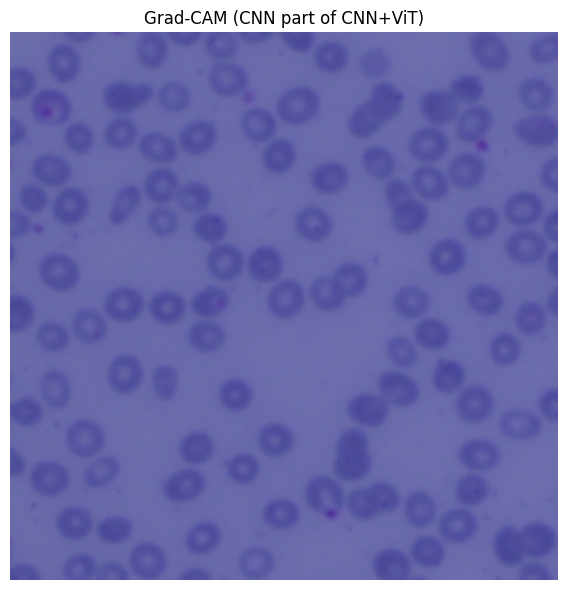

Attention visualization skipped: No such layer: resize_tokens. Existing layers are: ['input', 'conv_0_a', 'conv_0_b', 'pool_0', 'conv_1_a', 'conv_1_b', 'pool_1', 'conv_2_a', 'conv_2_b', 'pool_2', 'resizing', 'conv2d', 'flatten_tokens', 'add_position_embedding', 'blk0_ln1', 'blk0_mha', 'blk0_mha_res', 'blk0_ln2', 'blk0_mlp_fc1', 'blk0_mlp_drop', 'blk0_mlp_fc2', 'blk0_mlp_res', 'blk1_ln1', 'blk1_mha', 'blk1_mha_res', 'blk1_ln2', 'blk1_mlp_fc1', 'blk1_mlp_drop', 'blk1_mlp_fc2', 'blk1_mlp_res', 'blk2_ln1', 'blk2_mha', 'blk2_mha_res', 'blk2_ln2', 'blk2_mlp_fc1', 'blk2_mlp_drop', 'blk2_mlp_fc2', 'blk2_mlp_res', 'blk3_ln1', 'blk3_mha', 'blk3_mha_res', 'blk3_ln2', 'blk3_mlp_fc1', 'blk3_mlp_drop', 'blk3_mlp_fc2', 'blk3_mlp_res', 'pre_pool_ln', 'token_pool', 'dropout_8', 'dense', 'dropout_9', 'pred'].
Grad-CAM is the primary explainability tool.


In [ ]:
# 9. Explainability: Grad-CAM for CNN part (last Conv2D layer)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model

def get_last_conv_layer(model):
    """Find the last Conv2D layer in the model."""
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

def compute_gradcam(model, img_tensor):
    """Compute Grad-CAM for a single image tensor."""
    last_conv_name = get_last_conv_layer(model)

    grad_model = Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        loss = predictions[:, 0]  # binary target

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    # Weight conv feature maps
    cam = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    # Correct cv2.resize order (width, height)
    cam = cv2.resize(cam.numpy(), (IMAGE_SIZE[1], IMAGE_SIZE[0]))
    return cam

def overlay_gradcam(original_batch_image, cam, alpha=0.5):
    """Overlay Grad-CAM heatmap on original image."""
    img = original_batch_image.numpy()
    # Undo ImageNet normalization
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    img = (img * 255).astype("uint8")

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return overlay

# Visualize Grad-CAM for a few test images
for images, labels in test_ds.take(1):
    img_tensor = images[0:1]  # first image of batch
    cam = compute_gradcam(model, img_tensor)
    overlay = overlay_gradcam(images[0], cam)

    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Grad-CAM (CNN part of CNN+ViT)")
    plt.tight_layout()
    plt.show()

# 10. Optional: Visualize ViT attention for a chosen block
def build_attention_extractor(full_model, block_index=0):
    """Build submodel to extract attention scores from a transformer block."""
    # Layer names
    ln1_name = f"blk{block_index}_ln1"
    mha_name = f"blk{block_index}_mha"

    # Reconstruct path from input to MHA
    x = full_model.get_layer("input").output
    x = full_model.get_layer("conv_0_a")(x)
    x = full_model.get_layer("conv_0_b")(x)
    x = full_model.get_layer("pool_0")(x)
    x = full_model.get_layer("conv_1_a")(x)
    x = full_model.get_layer("conv_1_b")(x)
    x = full_model.get_layer("pool_1")(x)
    x = full_model.get_layer("conv_2_a")(x)
    x = full_model.get_layer("conv_2_b")(x)
    x = full_model.get_layer("pool_2")(x)
    x = full_model.get_layer("resize_tokens")(x)
    x = full_model.get_layer("patch_proj")(x)
    x = full_model.get_layer("flatten_tokens")(x)

    # Recreate positional embedding addition
    num_tokens = x.shape[1]
    positions = tf.range(start=0, limit=num_tokens, delta=1)
    pos_embedding = full_model.get_layer("pos_embedding")(positions)
    x = layers.Add()([x, pos_embedding])

    # LayerNorm + MHA
    ln1 = full_model.get_layer(ln1_name)
    x_norm = ln1(x)
    mha = full_model.get_layer(mha_name)
    _, attn_scores = mha(x_norm, x_norm, return_attention_scores=True)

    extractor = Model(inputs=full_model.input, outputs=attn_scores, name=f"attn_extractor_blk{block_index}")
    return extractor

# Optional attention visualization
try:
    attn_extractor = build_attention_extractor(model, block_index=0)
    for images, labels in test_ds.take(1):
        attn_scores = attn_extractor.predict(images[0:1], verbose=0)  # shape [1, num_heads, tokens, tokens]
        attn_scores = attn_scores[0]  # remove batch dim
        attn_mean = attn_scores.mean(axis=0)  # average heads

        plt.figure(figsize=(6,5))
        sns.heatmap(attn_mean, cmap="magma")
        plt.title("ViT Attention (Block 0, averaged over heads)")
        plt.xlabel("Key tokens")
        plt.ylabel("Query tokens")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("Attention visualization skipped:", e)
    print("Grad-CAM is the primary explainability tool.")